<a href="https://colab.research.google.com/github/anchalsoni2580-a11y/Anchal-soni/blob/main/mdp_lab_delivery_robot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Lab Practice: Markov Decision Process (MDP) Formulation

**Reinforcement Learning Lab**

## Objective
By the end of this lab, you will be able to:
1. State the formal definition of a Markov Decision Process (MDP).
2. Formulate a real-world sequential decision-making problem as an MDP.
3. Implement the MDP (states, actions, transition model, reward model) in Python.
4. Simulate the agent–environment interaction loop.
5. Solve the MDP for the optimal value function and policy using **Value Iteration**.



## 1. What is a Markov Decision Process?

A **Markov Decision Process** is the standard mathematical framework used to model
sequential decision-making, where an **agent** interacts with an **environment** over
a sequence of time steps and chooses **actions** to maximize its cumulative reward.

An MDP is formally defined as a tuple:

$$
\text{MDP} = (S, A, P, R, \gamma)
$$

- $S$ — the set of all possible **states** of the environment.
- $A$ — the set of all possible **actions** the agent can take (may depend on the state, $A(s)$).
- $P(s' \mid s, a)$ — the **transition model**: probability of moving to state $s'$ after
  taking action $a$ in state $s$.
- $R(s, a, s')$ — the **reward model**: the immediate reward received for that transition.
- $\gamma \in [0, 1]$ — the **discount factor**, controlling how much future rewards are
  worth compared to immediate rewards.

**Markov Property:** the future depends only on the *current* state and action — not on
the full history of how the agent got there:

$$
P(S_{t+1} \mid S_t, A_t) = P(S_{t+1} \mid S_t, A_t, S_{t-1}, A_{t-1}, \dots, S_0, A_0)
$$



## 2. Real-Time Example: Autonomous Delivery Robot Battery Management

Consider a **delivery robot** working in a warehouse (similar to an Amazon-style fulfilment
robot). At every time step, the robot must decide what to do based on its **battery level**:

- **Search** — go out and deliver a package (earns a good reward, but drains the battery).
- **Wait** — stay idle near the dock (small, safe reward, battery does not change).
- **Recharge** — return to the charging dock (only sensible when battery is Low; no reward,
  but battery becomes High again).

If the robot keeps **searching** while its battery is **Low**, there is a risk that the
battery dies mid-delivery — a human operator then has to rescue and recharge it manually,
which incurs a penalty (lost time, lost package).

This is a perfect real-time example of an MDP: the robot's decision at every step depends
only on its **current battery state** (Markov property), and it must balance
immediate reward (delivering now) against long-term risk (running out of battery).


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)   # reproducible results for the simulation later



## 3. Formally Defining Our MDP

We now map the delivery-robot story onto the formal MDP tuple $(S, A, P, R, \gamma)$:

- **States** $S$ = {`High`, `Low`} — the robot's battery level.
- **Actions** $A(s)$ — depends on the state:
  - From `High`: {`search`, `wait`}
  - From `Low`: {`search`, `wait`, `recharge`}
- **Discount factor** $\gamma = 0.9$ — the robot cares about future rewards, but slightly
  prefers rewards sooner.
- **Reward values** — chosen to reflect the story: delivering a package is the most
  valuable, waiting is a small safe reward, and running out of battery is a penalty.


In [5]:
states = ["High", "Low"]              # battery level of the delivery robot

actions = {                            # actions allowed in each state
    "High": ["search", "wait"],
    "Low":  ["search", "wait", "recharge"],
}

gamma = 0.9        # discount factor: how much the robot values future rewards

r_search = 4        # reward for finding & delivering a package while searching
r_wait   = 1         # reward for waiting near the dock (small, safe reward)
r_rescue = -3        # penalty: battery dies while searching from Low, robot is rescued

alpha = 0.7          # P(battery stays High | state=High, action=search)
beta  = 0.4          # P(battery stays Low  | state=Low,  action=search)



## 4. Transition Model $P(s' \mid s, a)$ and Reward Model $R(s, a, s')$

We store the MDP's dynamics in a single Python dictionary:

```
transitions[(state, action)] = [(probability, next_state, reward), ...]
```

Each entry lists every possible outcome of taking `action` in `state`, together with how
likely that outcome is and what reward it gives. Note that from `High`, searching *usually*
keeps the battery `High` (probability `alpha`), but sometimes drains it to `Low`. From `Low`,
searching *usually* keeps it `Low` (probability `beta`), but sometimes the battery dies and
the robot is rescued (moving it back to `High`, but with a penalty reward).


In [6]:
transitions = {
    ("High", "search"):   [(alpha,     "High", r_search),
                            (1 - alpha, "Low",  r_search)],
    ("High", "wait"):     [(1.0,       "High", r_wait)],

    ("Low",  "search"):   [(beta,      "Low",  r_search),
                            (1 - beta,  "High", r_rescue)],
    ("Low",  "wait"):     [(1.0,       "Low",  r_wait)],
    ("Low",  "recharge"): [(1.0,       "High", 0)],
}



## 5. Visualizing the Transition Table

Before running any algorithm, it always helps to see the full MDP laid out as a table —
every (state, action) pair, its possible next states, their probabilities, and rewards.


In [7]:
rows = []
for (s, a), outcomes in transitions.items():
    for prob, s2, reward in outcomes:
        rows.append([s, a, s2, prob, reward])

transition_table = pd.DataFrame(
    rows, columns=["State", "Action", "Next State", "Probability", "Reward"]
)
transition_table


,State,Action,Next State,Probability,Reward
0,High,search,High,0.7,4
1,High,search,Low,0.3,4
2,High,wait,High,1.0,1
3,Low,search,Low,0.4,4
4,Low,search,High,0.6,-3
5,Low,wait,Low,1.0,1
6,Low,recharge,High,1.0,0



## 6. Simulating the Agent–Environment Interaction Loop

This is the heart of any RL problem: at every time step, the agent looks at its current
state, picks an action (here, from a fixed demo policy), and the environment responds with
a next state sampled from $P(s' \mid s, a)$ and a reward. We repeat this loop to generate
one **episode** (a trajectory of experience).


In [8]:
def step(state, action):
    outcomes = transitions[(state, action)]
    probs = [o[0] for o in outcomes]
    choice = np.random.choice(len(outcomes), p=probs)
    _, next_state, reward = outcomes[choice]
    return next_state, reward


# a simple fixed policy just to demonstrate the loop (not yet the optimal one)
demo_policy = {"High": "search", "Low": "recharge"}

state = "High"
print("Simulating one episode (10 time steps):\n")
for t in range(10):
    action = demo_policy[state]
    next_state, reward = step(state, action)
    print(f"t={t}:  state={state:5s}  action={action:9s} ->  "
          f"next_state={next_state:5s}  reward={reward}")
    state = next_state


Simulating one episode (10 time steps):

t=0:  state=High   action=search    ->  next_state=High   reward=4
t=1:  state=High   action=search    ->  next_state=Low    reward=4
t=2:  state=Low    action=recharge  ->  next_state=High   reward=0
t=3:  state=High   action=search    ->  next_state=High   reward=4
t=4:  state=High   action=search    ->  next_state=High   reward=4
t=5:  state=High   action=search    ->  next_state=High   reward=4
t=6:  state=High   action=search    ->  next_state=High   reward=4
t=7:  state=High   action=search    ->  next_state=Low    reward=4
t=8:  state=Low    action=recharge  ->  next_state=High   reward=0
t=9:  state=High   action=search    ->  next_state=Low    reward=4



## 7. Solving the MDP: Value Iteration

The goal of solving an MDP is to find the **optimal policy** $\pi^*$ that maximizes
expected cumulative discounted reward. We do this with the **Bellman Optimality Equation**:

$$
V^*(s) = \max_{a \in A(s)} \sum_{s'} P(s' \mid s, a)\Big[R(s, a, s') + \gamma\, V^*(s')\Big]
$$

**Value Iteration** applies this equation repeatedly as an update rule, starting from
$V(s) = 0$ for all states, until the value function stops changing (converges).


In [11]:
V = {s: 0.0 for s in states}
history = [V.copy()]        # keep track of V after every iteration, for plotting later

for iteration in range(500):
    new_V = {}
    for s in states:
        q_values = []
        for a in actions[s]:
            q = sum(p * (r + gamma * V[s2]) for p, s2, r in transitions[(s, a)])
            q_values.append(q)
        new_V[s] = max(q_values)
    history.append(new_V.copy())

    if max(abs(new_V[s] - V[s]) for s in states) < 1e-6:
        V = new_V
        break
    V = new_V

# derive the optimal (greedy) policy from the converged value function
policy = {}
for s in states:
    best_action, best_q = None, -float("inf")
    for a in actions[s]:
        q = sum(p * (r + gamma * V[s2]) for p, s2, r in transitions[(s, a)])
        if q > best_q:
            best_action, best_q = a, q
    policy[s] = best_action

print(f"Value Iteration converged after {iteration + 1} iterations.")


Value Iteration converged after 143 iterations.



## 8. Results: Optimal Value Function and Policy

$V^*(s)$ tells us the best possible long-term expected reward from each battery state, and
$\pi^*(s)$ tells the robot exactly what to do in that state. The plot below shows how the
value estimates evolve, iteration by iteration, until they converge.


Optimal Value Function:
  V*(High) = 31.496
  V*(Low) = 28.346

Optimal Policy:
  pi*(High) = search
  pi*(Low) = recharge


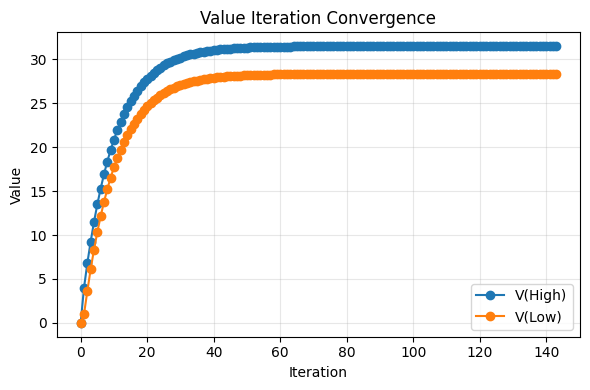

In [10]:
print("Optimal Value Function:")
for s in states:
    print(f"  V*({s}) = {V[s]:.3f}")

print("\nOptimal Policy:")
for s in states:
    print(f"  pi*({s}) = {policy[s]}")

plt.figure(figsize=(6, 4))
for s in states:
    plt.plot([h[s] for h in history], marker="o", label=f"V({s})")
plt.xlabel("Iteration")
plt.ylabel("Value")
plt.title("Value Iteration Convergence")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("value_iteration_convergence.png", dpi=150)
plt.show()



## 9. Lab Exercises (Try It Yourself)

1. Change `alpha` and `beta` to make the battery drain faster or slower, and observe how
   the optimal policy changes.
2. Make the `r_rescue` penalty much larger (e.g., -10). Does the robot still choose to
   `search` from `Low`?
3. Add a third battery state, `Medium`, with its own actions and transition probabilities.
4. Replace Value Iteration with **Policy Iteration** (evaluate a fixed policy fully, then
   improve it) and check that you get the same optimal policy.
5. Modify `demo_policy` in Section 6 to match the optimal policy found in Section 7, and
   re-run the simulation — compare the total reward earned over 10 steps.
